<a href="https://colab.research.google.com/github/volodymyr-holovan/Analysis_Cafe_Sales_DTA2026/blob/main/Analysis/cafe_eda_workbook_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Робочий зошит: Data Cleaning & EDA
## Датасет: Cafe Sales — Dirty Data for Cleaning Training

> **Ваше завдання:** самостійно заповнити всі клітинки з `# ВАШ КОД ТУТ`.
> Підказки є у кожному розділі — але спробуйте спочатку без них!


---
### Структура проєкту
- **Частина 1** — Первинна інспекція (Tasks 1.1–1.3)
- **Частина 2** — Очищення даних (Tasks 2.1–2.4)
- **Частина 3** — EDA та візуалізація (Tasks 3.1–3.5)
- **Частина 4** — Висновки

---

## ⚙️ Підготовка

Завантажте датасет: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Вкажіть шлях до файлу у змінній `FILE_IN` нижче.
Можливі варіанти:
- **Локально:** `FILE_IN = 'data/dirty_cafe_sales.csv'`
- **GitHub Raw URL:** вкажіть посилання на raw-файл
- **Google Colab + Drive:** змонтуйте диск і вкажіть шлях

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
# import warnings

# warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# FILE_IN = 'data/dirty_cafe_sales.csv'   # локальний варіант
FILE_IN = 'https://raw.githubusercontent.com/volodymyr-holovan/Analysis_Cafe_Sales_DTA2026/refs/heads/main/Data/dirty_cafe_sales.csv'

# FILE_OUT = 'data/cafe_sales_clean.csv'  # локальний варіант
FILE_OUT = 'cafe_sales_clean_v2.csv'

print('✓ Готово. Починаємо!')

✓ Готово. Починаємо!


---
# ЧАСТИНА 1 — Первинна інспекція

---

## Task 1.1 — Завантаження та перший огляд

**Що потрібно зробити:**
1. Прочитати CSV файл у датафрейм `df`
2. Зберегти оригінал у `df_original` (на випадок якщо щось піде не так)
3. Вивести перші 10 рядків
4. Викликати `.info()` і `.describe(include='all')`

**Зверніть увагу:** які колонки мають тип `object` замість числових? Чому?

In [3]:
# Завантаження датасету
df_original = pd.read_csv(FILE_IN)
df = df_original.copy()

print(f'Розмір: {df.shape[0]} рядків × {df.shape[1]} стовпців')  # замініть ???

# Перші 10 рядків
df.head(10)

Розмір: 10000 рядків × 8 стовпців


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [4]:
# Загальна інформація про датафрейм
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
# Описова статистика (для числових І текстових колонок)
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### ✏️ Спостереження після Task 1.1
*(Запишіть тут що ви помітили — підозрілі значення, неправильні типи, тощо)*

- Усі колонки, окрім Transaction ID, мають тип object, хоча Quantity, Price Per Unit і Total Spent мають бути числовими, а Transaction Date — датою. Причина — у даних трапляються текстові значення 'ERROR' та 'UNKNOWN', які не дають pandas автоматично розпізнати числовий/датовий тип.
- У describe(include='all') видно, що серед унікальних значень числових колонок є нечислові мітки (ERROR, UNKNOWN), а в Payment Method і Location найчастіше зустрічається саме UNKNOWN/Takeaway.
- Кількість непустих значень (non-null count) різна по колонках — це сигналізує про пропуски, які ще не видно у вигляді NaN, бо вони закодовані текстом.
- Назви колонок містять пробіли (Transaction ID, Price Per Unit) — незручно для звернення через крапку, треба буде привести до snake_case.

## Task 1.2 — Дублікати

**Що потрібно зробити:**
1. Порахувати кількість повних дублікатів
2. Видалити дублікати, зберігши перший зустрічний
3. Вивести кількість рядків до і після

**Підказка:** `df.duplicated()`, `df.drop_duplicates(keep=...)`

In [6]:
# Знайти дублікати
n_dupes = df.duplicated().sum()
print(f'Знайдено дублікатів: {n_dupes}')
print(f'Рядків до видалення: {len(df)}')

# Видалити дублікати
df.drop_duplicates(keep='first', inplace=True)

print(f'Рядків після видалення: {len(df)}')

Знайдено дублікатів: 0
Рядків до видалення: 10000
Рядків після видалення: 10000


## Task 1.3 — Аналіз пропущених значень

**Що потрібно зробити:**
1. Замінити значення `'ERROR'`, `'UNKNOWN'`, `''`, `' '` на `np.nan`
2. Порахувати пропуски по кожній колонці (кількість і %)
3. Порахувати загальний % пропусків
4. Побудувати **два** графіки: heatmap і bar chart

**Підказка:** `df.replace(список, np.nan)`, `df.isnull().sum()`

In [7]:
# Крок 1: замінити 'брудні' значення на NaN
df.replace(['ERROR', 'UNKNOWN', '', ' ', 'error', 'unknown'], np.nan, inplace=True)

# Крок 2: порахувати пропуски
missing_count = df.isna().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)  # (у відсотках від загальної кількості рядків)

missing_df = pd.DataFrame({'Пропусків': missing_count, '%': missing_pct})

# Показати тільки колонки де є пропуски
print(missing_df[missing_df['Пропусків'] > 0])

# Крок 3: загальний % пропусків
total_pct = df.isna().sum().sum() / df.size * 100
print(f'\nЗагальний % пропусків: {total_pct:.2f}%')

                  Пропусків      %
Item                    969   9.69
Quantity                479   4.79
Price Per Unit          533   5.33
Total Spent             502   5.02
Payment Method         3178  31.78
Location               3961  39.61
Transaction Date        460   4.60

Загальний % пропусків: 12.60%


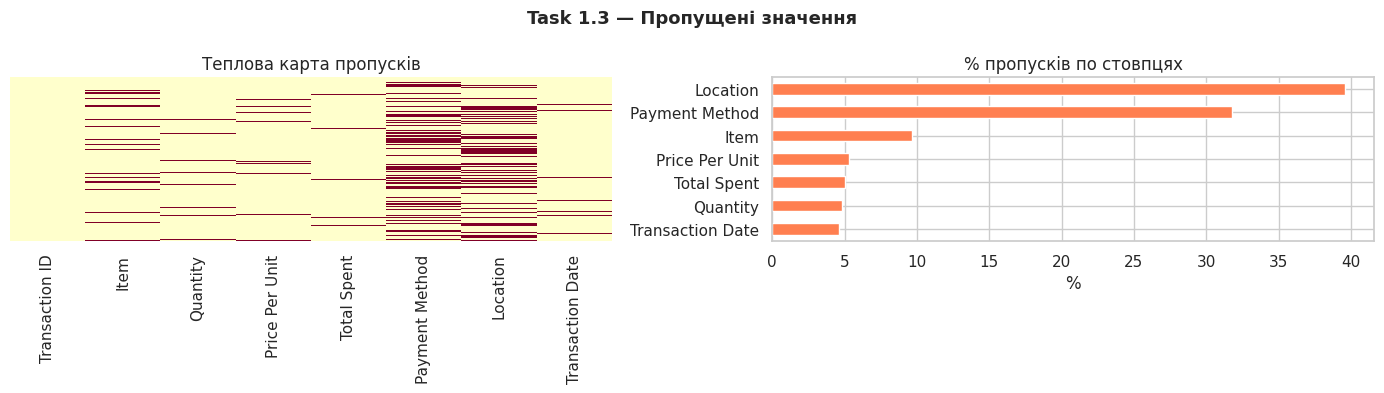

In [8]:
# Крок 4: візуалізація пропусків
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 1.3 — Пропущені значення', fontsize=13, fontweight='bold')

# Графік 1: Heatmap пропусків
# Підказка: sns.heatmap(df.isnull(), cbar=False, ...)
sns.heatmap(
    df.isna(),         # True/False матриця
    cbar=False,          # без шкали кольорів
    cmap='YlOrRd',       # жовтий=є значення, червоний=NaN
    yticklabels=False,   # не показуємо номери рядків (їх занадто багато)
    ax=axes[0]
)
axes[0].set_title('Теплова карта пропусків')

# Графік 2: Horizontal bar chart — % пропусків по колонках
# Підказка: .plot(kind='barh', ax=axes[1], ...)
missing_df[missing_df['Пропусків'] > 0]['%'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('% пропусків по стовпцях')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

---
# ЧАСТИНА 2 — Очищення даних

---

## Підготовка: перейменування колонок

Перейменуйте колонки: приберіть пробіли і зробіть назви у форматі `snake_case`.

| Стара назва | Нова назва |
|-------------|------------|
| `Transaction ID` | `transaction_id` |
| `Item` | `item` |
| `Quantity` | `quantity` |
| `Price Per Unit` | `price_per_unit` |
| `Total Spent` | `total_spent` |
| `Payment Method` | `payment_method` |
| `Location` | `location` |
| `Transaction Date` | `transaction_date` |

In [9]:
# Крок 1: прибрати пробіли з назв
df.columns = df.columns.str.strip()

# Крок 2: перейменувати
df = df.rename(columns={
    'Transaction ID'  : 'transaction_id',
    'Item'            : 'item',
    'Quantity'        : 'quantity',
    'Price Per Unit'  : 'price_per_unit',
    'Total Spent'     : 'total_spent',
    'Payment Method'  : 'payment_method',
    'Location'        : 'location',
    'Transaction Date': 'transaction_date',
})

print('Нові назви колонок:', list(df.columns))

Нові назви колонок: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


## Task 2.1 — Обробка пропусків у категорійних колонках

**Стратегії:**

| Колонка | Стратегія |
|---------|----------|
| `transaction_id` | Видалити рядок |
| `item` | По ціні зі словника (якщо є price) → інакше мода |
| `payment_method` | `'Unknown'` — рекомендовано; або мода (варіант Б) |
| `location` | `'Unknown'` — рекомендовано; або мода (варіант Б) |

**Підказки:**
- `df.dropna(subset=[...])` — видалити рядки де NaN у вказаних колонках
- `df['col'].fillna('Unknown')` — заповнити рядком
- Словник і мода для item — виконуються у Task 2.2 після конвертації числових типів

In [10]:
# transaction_id: видалити рядки де NaN
before = len(df)
df.dropna(subset=['transaction_id'], inplace=True)
print(f'Видалено рядків без transaction_id: {before - len(df)}')

# payment_method:
# Варіант А (рекомендований) — заповнити 'Unknown'
# df.payment_method.fillna('Unknown', inplace=True)

# Варіант Б — заповнити модою (розкоментуйте)
# mode_pay = df['payment_method'].mode()[0]
# df['payment_method'].fillna(mode_pay, inplace=True)

# location:
# Варіант А (рекомендований) — заповнити 'Unknown'
# df.location.fillna('Unknown', inplace=True)

# Варіант Б — заповнити модою (розкоментуйте)
# mode_loc = df['location'].mode()[0]
# df['location'].fillna(mode_loc, inplace=True)


df.fillna({'payment_method': 'Unknown', 'location': 'Unknown'}, inplace=True)

display(df[['payment_method', 'location']].isna().sum())


# item: заповнюємо у Task 2.2 після конвертації числових типів
mode_item = df['item'].mode()[0]  # зберігаємо заздалегідь
print(f'Зберегли mode_item = "{mode_item}" для резервного заповнення')

Видалено рядків без transaction_id: 0


,0
payment_method,0
location,0


Зберегли mode_item = "Juice" для резервного заповнення


## Task 2.2 — Конвертація типів і заповнення item / price / quantity

**Порядок дій:**
1. Конвертувати числові типи (`errors='coerce'`)
2. Побудувати словник `ITEM_PRICE` кодом: `item → мода ціни` з даних
3. **Ситуація 1:** item = NaN, price є → знайти item зі зворотного словника
4. **Ситуація 2:** item є, price = NaN → знайти price зі словника
5. **Ситуація 3:** обидва NaN → item = мода, price = по item
6. **quantity:** якщо є price і total → `qty = total / price`; інакше медіана по товару
7. Відновити `total_spent = qty × price`, перевірити збіг

**Підказки:**
```python
# Побудова словника з даних
df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
# Зворотний словник
{round(v,2): k for k, v in ITEM_PRICE.items()}
# Медіана по групі
df.groupby('item')['quantity'].transform('median')
```

In [11]:
# Конвертація числових колонок (errors='coerce' → некоректне стає NaN)
df['quantity']         = pd.to_numeric(df['quantity'], errors='coerce')
df['price_per_unit']   = pd.to_numeric(df['price_per_unit'], errors='coerce')
df['total_spent']      = pd.to_numeric(df['total_spent'], errors='coerce')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

print('Типи після конвертації:')
print(df.dtypes)

Типи після конвертації:
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
dtype: object


In [12]:
# Крок 0: будуємо словник ITEM_PRICE з даних (item → мода ціни)
# ITEM_PRICE = df.groupby('item')['price_per_unit'].agg(lambda x: x.mode().tolist()).to_dict()
ITEM_PRICE = (
    df
    .dropna(subset=['item','price_per_unit'])  # видаляємо рядки, де продукту та ціни одначосно немає (для того, щоб мода, раптово, не видала NaN)
    .groupby('item')['price_per_unit']
    .agg(lambda x: x.mode().tolist())
    .to_dict()
)

# Підказка:
# df.dropna(subset=['item','price_per_unit'])
#   .groupby('item')['price_per_unit']
#   .agg(lambda x: x.mode()[0])
#   .to_dict()

# Зворотний словник: ціна → товар
PRICE_ITEM = {}

for key, value in ITEM_PRICE.items():
  for el in value:
    PRICE_ITEM.setdefault(el, []).append(key)

# Підказка: {round(v, 2): k for k, v in ITEM_PRICE.items()}

print(f'Словник побудовано: {len(ITEM_PRICE)} товарів\n')

print("--- ITEM_PRICE ---")
print(pd.Series(ITEM_PRICE).sort_index())

print("\n--- PRICE_ITEM ---")
print(pd.Series(PRICE_ITEM).sort_index())

Словник побудовано: 8 товарів

--- ITEM_PRICE ---
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
dtype: object

--- PRICE_ITEM ---
1.0                [Cookie]
1.5                   [Tea]
2.0                [Coffee]
3.0           [Cake, Juice]
4.0    [Sandwich, Smoothie]
5.0                 [Salad]
dtype: object


In [13]:
df.describe(include='all')
df.price_per_unit.unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

In [14]:
np.random.default_rng(42)

# Ситуація 1: item = NaN, price є → знаходимо item по ціні
mask1 = df.item.isna() & df.price_per_unit.notna()

# df.loc[mask1, 'item'] = df.loc[mask1, 'price_per_unit'].round(2).map(np.random.choice(PRICE_ITEM[df.loc[mask1, 'price_per_unit']]))
df.loc[mask1, 'item'] = (
                          df.loc[mask1, 'price_per_unit']
                          .round(2)
                          .map(lambda price: np.random.choice(PRICE_ITEM[price]) if price in PRICE_ITEM else None)
                        )

# df.head(10)

# Підказка: .round(2).map(PRICE_ITEM)
print(f'Ситуація 1 (є price → item): {mask1.sum()} рядків')

Ситуація 1 (є price → item): 915 рядків


In [15]:
# Ситуація 2: item є, price = NaN → знаходимо ціну по товару
mask2 = df.item.notna() & df.price_per_unit.isna()

df.loc[mask2, 'price_per_unit'] = (
                                    df.loc[mask2, 'item']
                                    .map(lambda it: np.random.choice(ITEM_PRICE[it]) if it in ITEM_PRICE else None)
                                  )
# Підказка: .map(ITEM_PRICE)
print(f'Ситуація 2 (є item → price): {mask2.sum()} рядків')

Ситуація 2 (є item → price): 479 рядків


In [16]:
(df.item.isna() & df.price_per_unit.isna()).sum()

np.int64(54)

In [17]:
(df.item.isna() & df.price_per_unit.isna() & df.total_spent.isna()).sum()

np.int64(3)

In [18]:
(df.item.isna() & df.price_per_unit.isna() & df.quantity.isna()).sum()

np.int64(3)

In [19]:
(df.item.isna() & df.price_per_unit.isna() & df.quantity.isna() & df.total_spent.isna()).sum()

np.int64(0)

In [21]:
# Ситуація 3: обидва NaN → item = мода, price = по item
mask3 = df.item.isna() & df.price_per_unit.isna()  # item isna AND price isna
mode_item = df['item'].mode()[0]   # рахуємо після заповнення ситуацій 1 і 2
df.loc[mask3, 'item']           = mode_item
df.loc[mask3, 'price_per_unit'] = ITEM_PRICE.get(mode_item)[0]  # ITEM_PRICE.get(mode_item) повертає список — беремо перше значення
print(f'Ситуація 3 (обидва NaN → мода "{mode_item}"): {mask3.sum()} рядків')

print(f'\nNaN у item:           {df["item"].isna().sum()}')
print(f'NaN у price_per_unit: {df["price_per_unit"].isna().sum()}')

Ситуація 3 (обидва NaN → мода "Juice"): 54 рядків

NaN у item:           0
NaN у price_per_unit: 0


In [22]:
# Заповнення quantity
# Варіант А: є price і total_spent → qty = total / price
mask_qty = df.quantity.isna() & df.price_per_unit.notna() & df.total_spent.notna()  # quantity isna AND price notna AND total notna
df.loc[mask_qty, 'quantity'] = (df.loc[mask_qty, 'total_spent'] / df.loc[mask_qty, 'price_per_unit']).round()
print(f'quantity відновлено через total/price: {mask_qty.sum()} рядків')

# Варіант Б: решта NaN → медіана по товару
qty_median = df.groupby('item')['quantity'].transform('median')
df['quantity'] = df['quantity'].fillna(qty_median)
df['quantity'] = df['quantity'].round().astype('Int64')
print(f'quantity після медіани по товару: {df["quantity"].isna().sum()} NaN залишилось')

quantity відновлено через total/price: 459 рядків
quantity після медіани по товару: 0 NaN залишилось


In [23]:
# Відновлення total_spent там де він NaN
mask_total = (
    df.total_spent.isna() & df.quantity.notna() & df.price_per_unit.notna()  # total isna AND quantity notna AND price notna
)
df.loc[mask_total, 'total_spent'] = df.loc[mask_total, 'quantity'].astype(float) * df.loc[mask_total, 'price_per_unit']
print(f'total_spent відновлено (був NaN): {mask_total.sum()} рядків')

# Залишкові NaN total_spent → медіана
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].median())

total_spent відновлено (був NaN): 502 рядків


### Перевірка total_spent і рішення про розбіжності

Після відновлення порівняйте `total_spent` з `quantity × price_per_unit`.

Якщо є розбіжності — що з ними робити?

| Ситуація | Рішення |
|----------|---------|
| `total_spent` відновлювався з NaN | Перерахований вже правильний — залишити |
| `qty` або `price` відновлювались (мода/словник) | Перерахований надійніший — **перезаписати** |
| Всі поля були в оригіналі, але не збігаються | Помилка вводу — **перезаписати** |

У нашому проєкті — **перезаписуємо** скрізь де є розбіжність,
бо ціни зі словника надійніші за оригінал.

In [24]:
# Крок 1: порахувати очікуване значення для кожного рядка
df['_expected'] = (df['quantity'].astype(float) * df['price_per_unit']).round(2)  # qty × price, round(2)

# Крок 2: знайти рядки де total_spent не збігається з _expected
mask_mismatch = df['total_spent'].round(2) != df['_expected']
n_mismatch = mask_mismatch.sum()

print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch} рядків')

if n_mismatch > 0:
    # Крок 3: показати перші 5 розбіжностей
    print('\nПерші 5 (до виправлення):')
    print(df.loc[mask_mismatch,
                 ['item','quantity','price_per_unit','total_spent','_expected']].head())

    # Крок 4: ПЕРЕЗАПИСАТИ total_spent перерахованим значенням
    df.loc[mask_mismatch, 'total_spent'] = df.loc[mask_mismatch, '_expected']
    print(f'\n→ total_spent перезаписано для {n_mismatch} рядків')

df.drop(columns=['_expected'], inplace=True)

# Крок 5: фінальна перевірка — розбіжностей має бути 0
still_bad = (df['total_spent'].round(2) !=
             (df['quantity'].astype(float) * df['price_per_unit']).round(2)).sum()
print(f'\nФінальна перевірка: {still_bad} розбіжностей залишилось')

# Видалити рядки без дати
before = len(df)
df.dropna(subset=['transaction_date'], inplace=True)
print(f'Видалено рядків без дати: {before - len(df)}')

Збігів:       9963 / 10000
Розбіжностей: 37 рядків

Перші 5 (до виправлення):
      item  quantity  price_per_unit  total_spent  _expected
151  Juice         4             3.0         16.0       12.0
289  Juice         4             3.0          6.0       12.0
334  Juice         4             3.0          6.0       12.0
550  Juice         4             3.0          6.0       12.0
818  Juice         1             3.0          4.0        3.0

→ total_spent перезаписано для 37 рядків

Фінальна перевірка: 0 розбіжностей залишилось
Видалено рядків без дати: 460


## Task 2.3 — Стандартизація тексту

Приведіть `item`, `payment_method`, `location` до єдиного формату:
- Приберіть зайві пробіли (`.str.strip()`)
- Кожне слово з великої літери (`.str.title()`)

In [25]:
for col in ['item', 'payment_method', 'location']:
    df[col] = df[col].str.strip().str.title()

print('Унікальні payment_method:', sorted(df['payment_method'].unique()))
print('Унікальні location:',       sorted(df['location'].unique()))

Унікальні payment_method: ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']
Унікальні location: ['In-Store', 'Takeaway', 'Unknown']


## Task 2.4 — Feature Engineering

З колонки `transaction_date` витягніть нові ознаки:

| Нова колонка | Що містить | Підказка |
|-------------|------------|----------|
| `year` | Рік (число) | `.dt.year` |
| `month` | Місяць (число 1–12) | `.dt.month` |
| `month_name` | Назва місяця рядком | `.dt.strftime('%B')` |
| `weekday` | Назва дня тижня | `.dt.day_name()` |
| `is_weekend` | True якщо сб/нд | `.isin(['Saturday', 'Sunday'])` |

In [26]:
df['year']       = df['transaction_date'].dt.year
df['month']      = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%B')
df['weekday']    = df['transaction_date'].dt.day_name()
df['week']       = df['transaction_date'].dt.isocalendar().week.astype('Int64')
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

# Перевірка логічності
df = df[df['quantity'] > 0]
df = df[df['total_spent'] > 0]

print(f'✓ Фінальний датасет: {df.shape}')
print('\nПерші рядки з новими колонками:')
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'is_weekend']].head()

✓ Фінальний датасет: (9540, 14)

Перші рядки з новими колонками:


,transaction_date,year,month,month_name,weekday,is_weekend
0,2023-09-08,2023,9,September,Friday,False
1,2023-05-16,2023,5,May,Tuesday,False
2,2023-07-19,2023,7,July,Wednesday,False
3,2023-04-27,2023,4,April,Thursday,False
4,2023-06-11,2023,6,June,Sunday,True


In [27]:
# Зберегти чистий файл
df_tableau = df.copy()
df_tableau['transaction_date'] = df_tableau['transaction_date'].dt.strftime('%Y-%m-%d')
df_tableau['is_weekend'] = df_tableau['is_weekend'].map({True: 'Yes', False: 'No'})
df_tableau.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')
print(f'✓ Збережено: {FILE_OUT} — готовий для Tableau!')

✓ Збережено: cafe_sales_clean_v2.csv — готовий для Tableau!


---
# ЧАСТИНА 3 — EDA

---

## Task 3.1 — Топ товари

**Що потрібно:**
1. Топ-5 товарів за `quantity` (кількість)
2. Топ-5 товарів за `total_spent` (виторг)
3. Два bar chart поруч — один для кожного топу

**Підказка:** `df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)`

In [28]:
# Топ-5 за кількістю
top_qty = df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)

# Топ-5 за виторгом
top_rev = df.groupby('item')['total_spent'].sum().sort_values(ascending=False).head(5)

print('Топ-5 за кількістю:')
print(top_qty.to_string())
print('\nТоп-5 за виторгом:')
print(top_rev.round(2).to_string())

Топ-5 за кількістю:
item
Juice       3883
Coffee      3755
Salad       3646
Sandwich    3604
Cake        3598

Топ-5 за виторгом:
item
Salad       18230.0
Sandwich    14416.0
Smoothie    14024.0
Juice       11649.0
Cake        10794.0


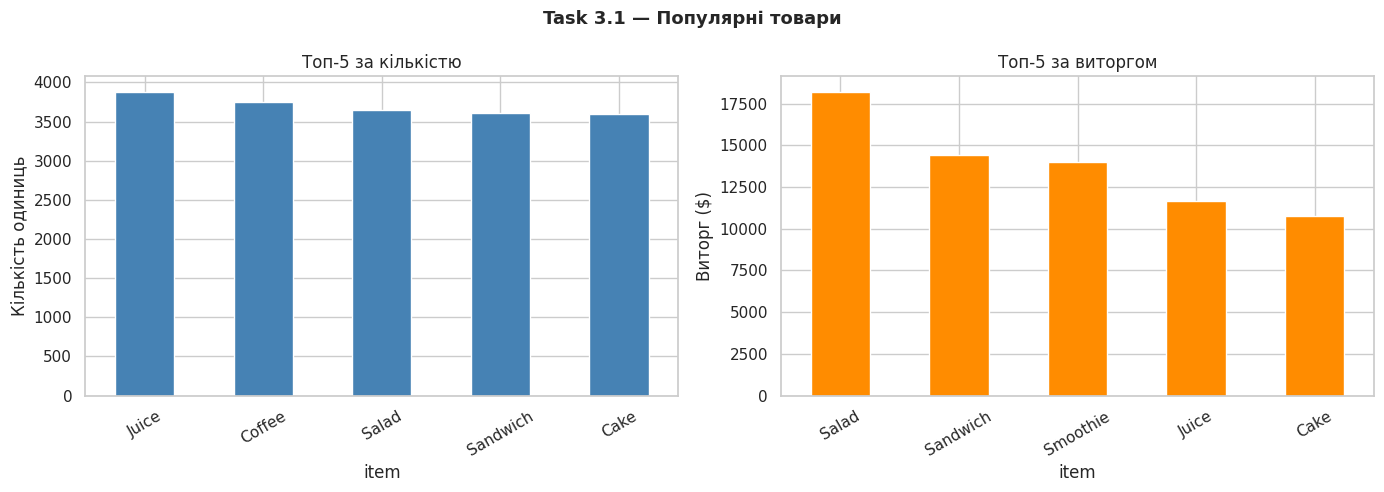

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3.1 — Популярні товари', fontsize=13, fontweight='bold')

# Графік 1: топ за кількістю
top_qty.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Топ-5 за кількістю')
axes[0].set_ylabel('Кількість одиниць')
axes[0].tick_params(axis='x', rotation=30)

# Графік 2: топ за виторгом
top_rev.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Топ-5 за виторгом')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task31.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.1
*(Що помітили? Чи збігаються топи за кількістю та виторгом?)*

- Топи за кількістю та за виторгом не повністю збігаються. За кількістю проданих одиниць лідирує Coffee, який купують найчастіше, але він дешевий.
- За виторгом лідирує Salad — дорожчий товар, який продається рідше за кількістю, але приносить більше грошей за рахунок вищої ціни за одиницю.

## Task 3.2 — Payment Method та Location

**Що потрібно:**
1. Загальний виторг по `payment_method` — pie chart
2. Загальний виторг по `location` — bar chart

**Підказка:** `df.groupby('payment_method')['total_spent'].sum()`

In [30]:
rev_pay = df.groupby('payment_method')['total_spent'].sum().sort_values(ascending=False)
rev_loc = df.groupby('location')['total_spent'].sum().sort_values(ascending=False)

print('Виторг по оплаті:')
print(rev_pay.round(2).to_string())
print('\nВиторг по локації:')
print(rev_loc.round(2).to_string())

Виторг по оплаті:
payment_method
Unknown           26454.0
Digital Wallet    19605.5
Cash              19571.0
Credit Card       19542.5

Виторг по локації:
location
Unknown     33739.5
In-Store    25978.0
Takeaway    25455.5


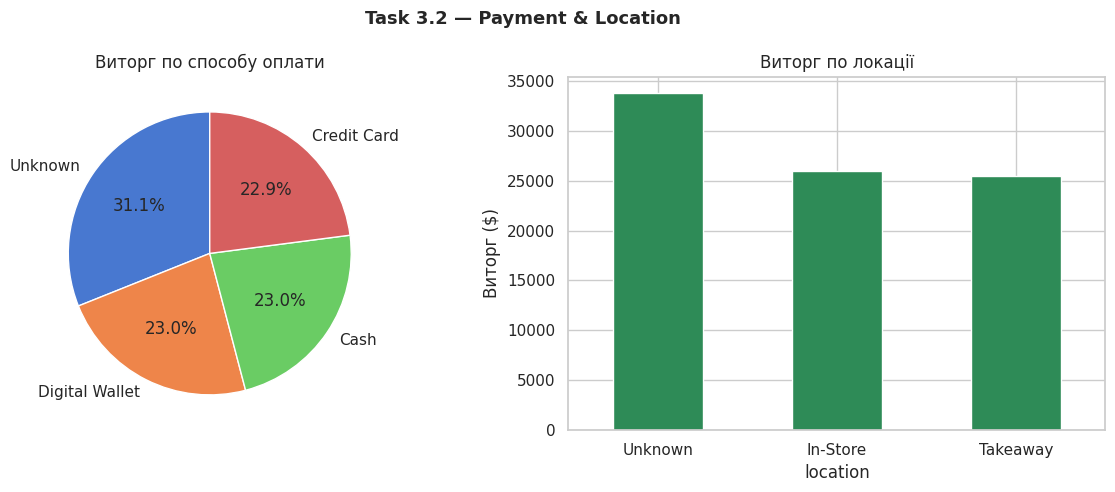

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.2 — Payment & Location', fontsize=13, fontweight='bold')

# Pie chart — payment_method
axes[0].pie(rev_pay, labels=rev_pay.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted'))
axes[0].set_title('Виторг по способу оплати')

# Bar chart — location
rev_loc.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Виторг по локації')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('part3_task32.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.2

- Який спосіб оплати домінує: формально найбільший виторг показує категорія Unknown — це наслідок дуже високої частки пропусків у payment_method (~32% від вихідних даних), а не реальна перевага якогось способу оплати. Серед "відомих" способів оплати Digital Wallet, Cash і Credit Card мають майже однаковий виторг — суттєвої переваги жодного з них немає.
- In-store чи Takeaway більше: тут також категорія Unknown (через ~40% пропусків у location) формально найбільша. Серед реальних значень In-Store трохи випереджає Takeaway, але різниця невелика — обидва формати майже однаково важливі для бізнесу.

## Task 3.3 — Часові тренди

**Що потрібно:**
1. Щоденний виторг — лінійний графік
2. Щомісячний виторг — bar chart
3. Середній виторг по днях тижня — bar chart (червоний = вихідні)

**Підказки:**
- `df.groupby('transaction_date')['total_spent'].sum().reset_index()`
- `df.groupby('weekday')['total_spent'].mean().reindex(dow_order)`
- Правильний порядок: `['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']`

In [32]:
# Щоденний виторг
daily_rev = df.groupby('transaction_date')['total_spent'].sum().reset_index()

# Щомісячний виторг
monthly_rev = df.groupby(['year', 'month', 'month_name'])['total_spent'].sum().reset_index()

# По днях тижня (середнє)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_dow = df.groupby('weekday')['total_spent'].mean().reindex(dow_order)

print(f'Найкращий день: {avg_dow.idxmax()}')
print(f'Найгірший день: {avg_dow.idxmin()}')

Найкращий день: Tuesday
Найгірший день: Wednesday


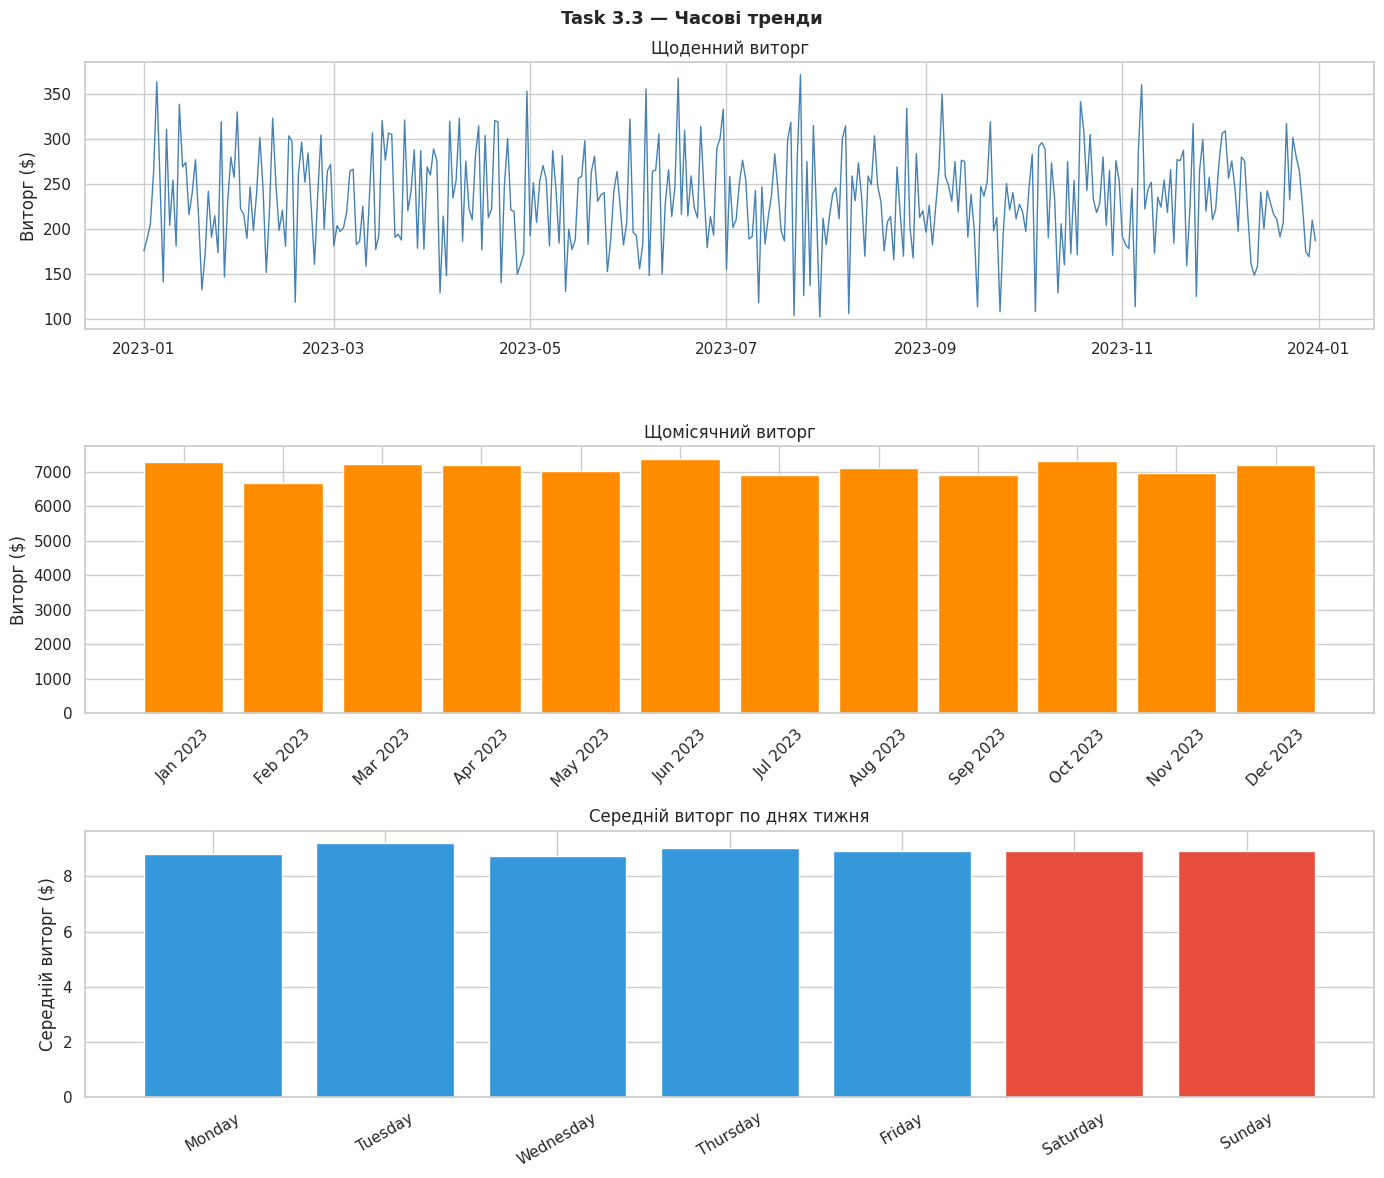

Місяць з найнижчим виторгом: February


In [33]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Task 3.3 — Часові тренди', fontsize=13, fontweight='bold')

# Графік 1: щоденний лінійний
axes[0].plot(daily_rev['transaction_date'], daily_rev['total_spent'], color='steelblue', linewidth=1)
axes[0].set_title('Щоденний виторг')
axes[0].set_ylabel('Виторг ($)')

# Графік 2: щомісячний бар
# Підказка: зробіть колонку label = перші 3 літери місяця + рік
monthly_rev['label'] = monthly_rev['month_name'].str[:3] + ' ' + monthly_rev['year'].astype(str)
axes[1].bar(monthly_rev['label'], monthly_rev['total_spent'], color='darkorange', edgecolor='white')
axes[1].set_title('Щомісячний виторг')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=45)

# Графік 3: по днях тижня (вихідні = червоні, будні = сині)
colors_dow = ['#E74C3C' if d in ['Saturday','Sunday'] else '#3498DB' for d in avg_dow.index]
axes[2].bar(avg_dow.index, avg_dow.values, color=colors_dow, edgecolor='white')
axes[2].set_title('Середній виторг по днях тижня')
axes[2].set_ylabel('Середній виторг ($)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task33.png', dpi=130, bbox_inches='tight')
plt.show()

# Знайти місяць з найнижчим виторгом
worst_month = monthly_rev.loc[monthly_rev['total_spent'].idxmin(), 'month_name']
print(f'Місяць з найнижчим виторгом: {worst_month}')

### ✏️ Висновок до Task 3.3

- Найкращий день тижня: Tuesday (вівторок) — середній виторг за день найвищий.
- Найгірший день тижня: Wednesday (середа) — середній виторг найнижчий, хоча різниця між днями тижня загалом невелика (приблизно 8.7–9.2 у середньому), тобто продажі по днях тижня досить рівномірні без яскраво вираженого "провального" дня.
- Найгірший місяць: February (лютий) — найнижчий сукупний виторг, що частково пояснюється коротшим місяцем (28 днів проти ~30-31 в інших).
- Є сезонний тренд? Виражена сезонність відсутня — щомісячний виторг коливається в межах приблизно 6 600–7 400 $, без яскраво вираженого зростання чи спаду протягом року. Це означає, що попит у кафе достатньо стабільний цілий рік.

## Task 3.4 — Виявлення викидів

**Що потрібно:**
1. Побудувати boxplot для `quantity` і `total_spent`
2. Розрахувати межі викидів методом IQR
3. Порахувати кількість викидів
4. Прийняти рішення: видалити, залишити або кепувати

**Формули IQR:**
```
IQR = Q3 - Q1
Нижня межа = Q1 - 1.5 × IQR
Верхня межа = Q3 + 1.5 × IQR
```

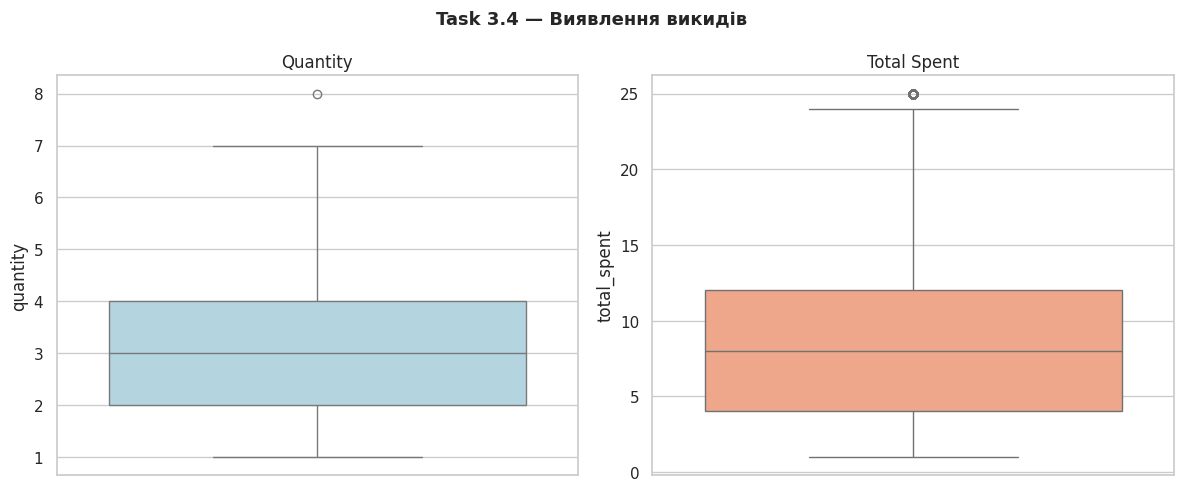

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.4 — Виявлення викидів', fontsize=13, fontweight='bold')

# Boxplot для quantity
sns.boxplot(y=df['quantity'].astype(float), ax=axes[0], color='lightblue')
axes[0].set_title('Quantity')

# Boxplot для total_spent
sns.boxplot(y=df['total_spent'].astype(float), ax=axes[1], color='lightsalmon')
axes[1].set_title('Total Spent')

plt.tight_layout()
plt.savefig('part3_task34.png', dpi=130, bbox_inches='tight')
plt.show()

In [35]:
# Кількісний аналіз викидів методом IQR
Q1  = df['total_spent'].quantile(0.25)   # 25-й перцентиль total_spent
Q3  = df['total_spent'].quantile(0.75)   # 75-й перцентиль
IQR = Q3 - Q1

low  = Q1 - 1.5 * IQR   # нижня межа
high = Q3 + 1.5 * IQR   # верхня межа

n_outliers = ((df['total_spent'] < low) | (df['total_spent'] > high)).sum()  # кількість значень поза межами

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Нормальний діапазон: [{low:.2f}, {high:.2f}]')
print(f'Кількість викидів: {n_outliers}')

Q1=4.00, Q3=12.00, IQR=8.00
Нормальний діапазон: [-8.00, 24.00]
Кількість викидів: 259


### ✏️ Рішення щодо викидів
*(Напишіть своє рішення та обгрунтування)*

Рішення: залишити

Обгрунтування: Метод IQR позначив як викиди ~2.7% рядків (259 з 9 540), однак це не помилкові чи фізично неможливі значення — це звичайні транзакції з відносно високим чеком. Видалення цих рядків штучно занизило б реальний виторг і спотворило б уявлення про справжню поведінку клієнтів. Оскільки значення total_spent уже узгоджені з quantity × price_per_unit (розбіжностей 0), немає підстав вважати ці точки помилками вводу — тому викиди залишаємо в датасеті для подальшого аналізу.

## Task 3.5 — Кореляційний аналіз

**Що потрібно:**
1. Порахувати кореляційну матрицю для `quantity`, `price_per_unit`, `total_spent`
2. Побудувати heatmap
3. Інтерпретувати результати

**Підказка:** `df[cols].astype(float).corr()`

Кореляційна матриця:
                quantity  price_per_unit  total_spent
quantity           1.000           0.008        0.706
price_per_unit     0.008           1.000        0.646
total_spent        0.706           0.646        1.000


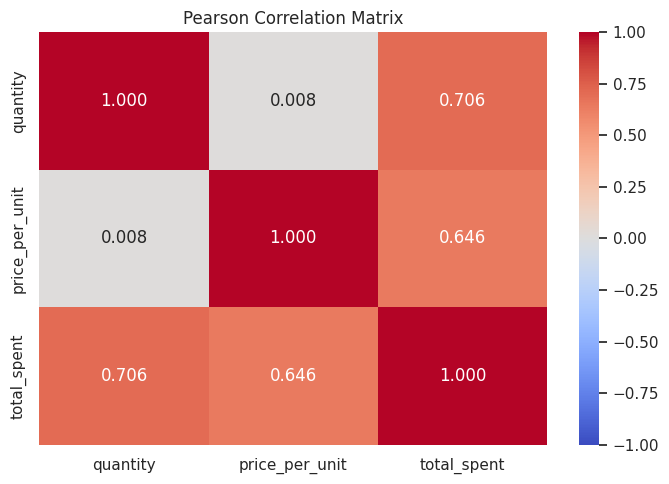

In [36]:
corr_cols   = ['quantity', 'price_per_unit', 'total_spent']
corr_matrix = df[corr_cols].astype(float).corr()

print('Кореляційна матриця:')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

# Heatmap кореляцій
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('part3_task35.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Інтерпретація кореляцій

| Пара | Значення | Сила | Пояснення |
|------|----------|------|-----------|
| total_spent ↔ quantity | ≈ 0.70 | Помірно сильна, позитивна | Що більше одиниць товару купують за транзакцію, то вищий загальний чек — очікувана й логічна залежність. |
| total_spent ↔ price_per_unit | ≈ 0.65 | Помірно сильна, позитивна | Дорожчі товари (наприклад, `Salad`) дають більший внесок у виторг навіть при меншій кількості одиниць. |
| quantity ↔ price_per_unit | ≈ 0.01 | Дуже слабка / відсутня | Кількість товару в чеку практично не залежить від його ціни — клієнти не купують менше дорогих товарів і не купують суттєво більше дешевих. Це означає, що `total_spent` формується **двома незалежними чинниками** — кількістю та ціною, — і обидва варто враховувати окремо при прогнозуванні виторгу.

---
# ЧАСТИНА 4 — Висновки та рекомендації

---

In [37]:
# Зберіть всі ключові метрики і надрукуйте підсумковий звіт

top_item_rev  = top_rev.idxmax()                                # найприбутковіший товар
top_item_qty  = top_qty.idxmax()                                # найпопулярніший за кількістю
top_pay       = rev_pay.idxmax()                                # домінуючий спосіб оплати
top_loc       = rev_loc.idxmax()                                # топ локація
total_revenue = df['total_spent'].sum()
avg_check     = df['total_spent'].mean()

print('=' * 55)
print('  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ')
print('=' * 55)

# Напишіть свій звіт тут — власними словами!
print(f'''
Загальний виторг за період:        ${total_revenue:,.2f}
Середній чек:                      ${avg_check:,.2f}
Кількість транзакцій:              {len(df):,}

Найприбутковіший товар:            {top_item_rev} (виторг {top_rev.max():,.2f} $)
Найпопулярніший товар (к-сть):     {top_item_qty} ({top_qty.max():,} од.)
Домінуючий спосіб оплати:          {top_pay} ({rev_pay.max():,.2f} $)
Найбільш прибуткова локація:       {top_loc} ({rev_loc.max():,.2f} $)

Найкращий день тижня за виторгом:  {avg_dow.idxmax()}
Найгірший день тижня за виторгом:  {avg_dow.idxmin()}
Місяць з найнижчим виторгом:       {worst_month}

Кореляція quantity ↔ total_spent:       {corr_matrix.loc["quantity","total_spent"]:.3f}
Кореляція price_per_unit ↔ total_spent: {corr_matrix.loc["price_per_unit","total_spent"]:.3f}

Викидів за total_spent (IQR-метод): {n_outliers} рядків ({n_outliers/len(df)*100:.1f}% від датасету)
''')
print('=' * 55)

  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ

Загальний виторг за період:        $85,173.00
Середній чек:                      $8.93
Кількість транзакцій:              9,540

Найприбутковіший товар:            Salad (виторг 18,230.00 $)
Найпопулярніший товар (к-сть):     Juice (3,883 од.)
Домінуючий спосіб оплати:          Unknown (26,454.00 $)
Найбільш прибуткова локація:       Unknown (33,739.50 $)

Найкращий день тижня за виторгом:  Tuesday
Найгірший день тижня за виторгом:  Wednesday
Місяць з найнижчим виторгом:       February

Кореляція quantity ↔ total_spent:       0.706
Кореляція price_per_unit ↔ total_spent: 0.646

Викидів за total_spent (IQR-метод): 259 рядків (2.7% від датасету)



## 📊 Загальні висновки та рекомендації бізнесу

### Підсумок аналізу

За весь період (2023 рік, після очищення — 9 540 транзакцій) кафе отримало загальний виторг **$85,173** із середнім чеком **$8.93**.


### Рекомендації для власника кафе

1. Покращити фіксацію способу оплати та локації в POS-системі. Майже третина чеків не має способу оплати, а 40% — локації. Неможливо достовірно оцінити, чи дійсно якийсь канал оплати або формат продажу домінує.
2. Активніше просувати товари з високою маржею (Salad, Sandwich, Smoothie) через крос-продажі з Coffee — найпопулярнішим, але не найприбутковішим товаром. Наприклад, комбо "кава + салат/сендвіч" може підвищити середній чек.

## ✅ Фінальний чеклист

Поставте ✓ навпроти кожного виконаного пункту:

**Частина 1**
- [✓] Завантажено і оглянуто датасет
- [✓] Знайдено і видалено дублікати
- [✓] Порахована і візуалізована кількість пропусків

**Частина 2**
- [✓] Перейменовано колонки
- [✓] Замінено ERROR/UNKNOWN на NaN
- [✓] Заповнено пропуски payment_method і location
- [✓] Конвертовано типи даних
- [✓] Побудовано словник ITEM_PRICE з даних
- [✓] Оброблено три ситуації item/price
- [✓] Відновлено quantity (через total/price або медіана по товару)
- [✓] Відновлено total_spent, перевірено збіг і перезаписано розбіжності
- [✓] Стандартизовано текст
- [✓] Додано часові ознаки
- [✓] Збережено FILE_OUT

**Частина 3**
- [✓] Task 3.1: топ товари — два бар-чарти
- [✓] Task 3.2: оплата і локація — pie + bar
- [✓] Task 3.3: часові тренди — 3 графіки
- [✓] Task 3.4: boxplot + IQR аналіз
- [✓] Task 3.5: кореляційна матриця + heatmap

**Частина 4**
- [✓] Підсумковий звіт з конкретними числами
- [✓] Мінімум 1 бізнес-рекомендація

---
**🎉 Вітаємо з завершенням проєкту!**